# Movie Recommendation System

In [ ]:
# Cell 1: install (uncomment if running in a fresh environment)
# !pip install -q pandas numpy matplotlib scikit-learn notebook seaborn
# If you already have packages installed, leave commented


## **Part 1: Exploring and Cleaning Data**

### Inspecting the Dataset Format

The dataset is not in a traditional CSV format. To examine its structure, use the following shell command to display the first 10 lines of the file:

```sh
!head <file_name>


**In the cells given below. Write the code to read the files.**

In [ ]:
# u.data
!head u.data


196	242	3	881250949
186	302	3	891717742
22	377	1	878887116
244	51	2	880606923
166	346	1	886397596
298	474	4	884182806
115	265	2	881171488
253	465	5	891628467
305	451	3	886324817
6	86	3	883603013


In [ ]:
# u.item
!head u.item


1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0
2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0
3|Four Rooms (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0
4|Get Shorty (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995)|0|1|0|0|0|1|0|0|1|0|0|0|0|0|0|0|0|0|0
5|Copycat (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Copycat%20(1995)|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|1|0|0
6|Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)|01-Jan-1995||http://us.imdb.com/Title?Yao+a+yao+yao+dao+waipo+qiao+(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0
7|Twelve Monkeys (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Twelve%20Monkeys%20(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|1|0|0|0
8|Babe (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Babe%20(1995)|0|0|0|0|1

In [ ]:
# u.user
!head u.user


1|24|M|technician|85711
2|53|F|other|94043
3|23|M|writer|32067
4|24|M|technician|43537
5|33|F|other|15213
6|42|M|executive|98101
7|57|M|administrator|91344
8|36|M|administrator|05201
9|29|M|student|01002
10|53|M|lawyer|90703


#### Loading the Dataset with Pandas

Use **pandas** to load the dataset into a DataFrame for analysis. Follow these steps:  

1. Import the necessary library: `pandas`.  
2. Use `pd.read_csv()` (or an appropriate function) to read the dataset file.  
3. Ensure the dataset is loaded with the correct delimiter (e.g., `','`, `'\t'`,`'|'` , or another separator if needed).  
4. Select and display the first few rows using `.head()`.

Ensure that:  

- The `ratings` dataset is read from `"u.data"` using tab (`'\t'`) as a separator and column names (`"user_id"`, `"movie_id"`, `"rating"` and `"timestamp"`).  
- The `movies` dataset is read from `"u.item"` using `'|'` as a separator, use columns (`0`, `1`, `2`), encoding (`"latin-1"`) and name the columns (`movie_id`, `title`, and `release_date`).  
- The `users` dataset is read from `"u.user"` using `'|'` as a separator, use columns (`0`, `1`, `2`, `3`) and name the columns (`user_id`, `age`, `gender`, and `occupation`).

In [ ]:
# ratings
import pandas as pd
import numpy as np

# Read ratings data
ratings = pd.read_csv('u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
ratings.head()


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# movies
# Read movies data
movies = pd.read_csv('u.item', sep='|', usecols=[0, 1, 2], encoding='latin-1', names=['movie_id', 'title', 'release_date'])
movies.head()


,movie_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995


In [ ]:
# users
# Read users data
users = pd.read_csv('u.user', sep='|', usecols=[0, 1, 2, 3], names=['user_id', 'age', 'gender', 'occupation'])
users.head()


,user_id,age,gender,occupation
0,1,24,M,technician
1,2,53,F,other
2,3,23,M,writer
3,4,24,M,technician
4,5,33,F,other


**Note:** As a **Bonus** task save the `ratings`, `movies` and `users` dataframe created into a `.csv` file format. <br>
**Hint:** Use the `to_csv()` function in pandas to save these DataFrames as CSV files.

In [ ]:
# ratings
# Save ratings dataframe to CSV (Bonus task)
ratings.to_csv('ratings.csv', index=False)
print("ratings.csv saved successfully!")


ratings.csv saved successfully!


In [ ]:
# movies
# Save movies dataframe to CSV (Bonus task)
movies.to_csv('movies.csv', index=False)
print("movies.csv saved successfully!")


movies.csv saved successfully!


In [ ]:
# users
# Save users dataframe to CSV (Bonus task)
users.to_csv('users.csv', index=False)
print("users.csv saved successfully!")


users.csv saved successfully!


**Display the first 10 rows of each file.**

In [ ]:
# ratings
ratings.head(10)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [ ]:
# movies
movies.head(10)


,movie_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,01-Jan-1995
6,7,Twelve Monkeys (1995),01-Jan-1995
7,8,Babe (1995),01-Jan-1995
8,9,Dead Man Walking (1995),01-Jan-1995
9,10,Richard III (1995),22-Jan-1996


In [ ]:
# users
users.head(10)


,user_id,age,gender,occupation
0,1,24,M,technician
1,2,53,F,other
2,3,23,M,writer
3,4,24,M,technician
4,5,33,F,other
5,6,42,M,executive
6,7,57,M,administrator
7,8,36,M,administrator
8,9,29,M,student
9,10,53,M,lawyer


### Data Cleaning and Exploration with Pandas  

After loading the dataset, it’s important to clean and explore the data to ensure consistency and accuracy. Below are key **pandas** functions for cleaning and understanding the dataset.

#### 1. Handle Missing Values  
- `df.dropna()` – Removes rows with missing values.  
- `df.fillna(value)` – Fills missing values with a specified value.  

#### 2. Remove Duplicates  
- `df.drop_duplicates()` – Drops duplicate rows from the dataset.  

#### 3. Handle Incorrect Data Types  
- `df.astype(dtype)` – Converts columns to the appropriate data type.  

#### 4. Filter Outliers (if applicable)  
- `df[df['column_name'] > threshold]` – Filters rows based on a condition.  

#### 5. Rename Columns (if needed)  
- `df.rename(columns={'old_name': 'new_name'})` – Renames columns for clarity.  

#### 6. Reset Index  
- `df.reset_index(drop=True, inplace=True)` – Resets the index after cleaning.  

### Data Exploration Functions  

To better understand the dataset, use these **pandas** functions:  

- `df.shape` – Returns the number of rows and columns in the dataset.  
- `df.nunique()` – Displays the number of unique values in each column.  
- `df['column_name'].unique()` – Returns unique values in a specific column.  

**Example Usage in Pandas:**  
```python
import pandas as pd

# Load dataset
df = pd.read_csv("your_file.csv")

# Drop missing values
df_cleaned = df.dropna()

# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Convert 'timestamp' column to datetime format
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])

# Display dataset shape
print("Dataset shape:", df_cleaned.shape)

# Display number of unique values in each column
print("Unique values per column:\n", df_cleaned.nunique())

# Display unique movie IDs
print("Unique movie IDs:", df_cleaned['movie_id'].unique()[:10])  # Show first 10 unique movie IDs


**Note:** The functions mentioned above are some of the widely used **pandas** functions for data cleaning and exploration. However, it is not necessary that all of these functions will be required in the exercises below. Use them as needed based on the dataset and the specific tasks.

**Convert Timestamps into Readable dates.**

In [ ]:
# ratings
# Convert timestamps to readable dates
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()


,user_id,movie_id,rating,timestamp
0,196,242,3,1997-12-04 15:55:49
1,186,302,3,1998-04-04 19:22:22
2,22,377,1,1997-11-07 07:18:36
3,244,51,2,1997-11-27 05:02:03
4,166,346,1,1998-02-02 05:33:16


**Check for Missing Values**

In [ ]:
# ratings
print("Missing values in ratings:")
print(ratings.isnull().sum())
print("\nTotal missing values:", ratings.isnull().sum().sum())


Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Total missing values: 0


In [ ]:
# movies
print("Missing values in movies:")
print(movies.isnull().sum())
print("\nTotal missing values:", movies.isnull().sum().sum())


Missing values in movies:
movie_id        0
title           0
release_date    1
dtype: int64

Total missing values: 1


In [ ]:
# users
print("Missing values in users:")
print(users.isnull().sum())
print("\nTotal missing values:", users.isnull().sum().sum())


Missing values in users:
user_id       0
age           0
gender        0
occupation    0
dtype: int64

Total missing values: 0


**Print the total number of users, movies, and ratings.**

In [ ]:
print(f"Total Users: {users['user_id'].nunique()}")
print(f"Total Movies: {movies['movie_id'].nunique()}")
print(f"Total Ratings: {len(ratings)}")
print(f"\nAverage rating: {ratings['rating'].mean():.2f}")
print(f"Rating range: {ratings['rating'].min()} to {ratings['rating'].max()}")

Total Users: 943
Total Movies: 1682
Total Ratings: 100000

Average rating: 3.53
Rating range: 1 to 5


### **Data Visualization and Analysis**

Let's create visualizations to better understand the dataset and gain insights.


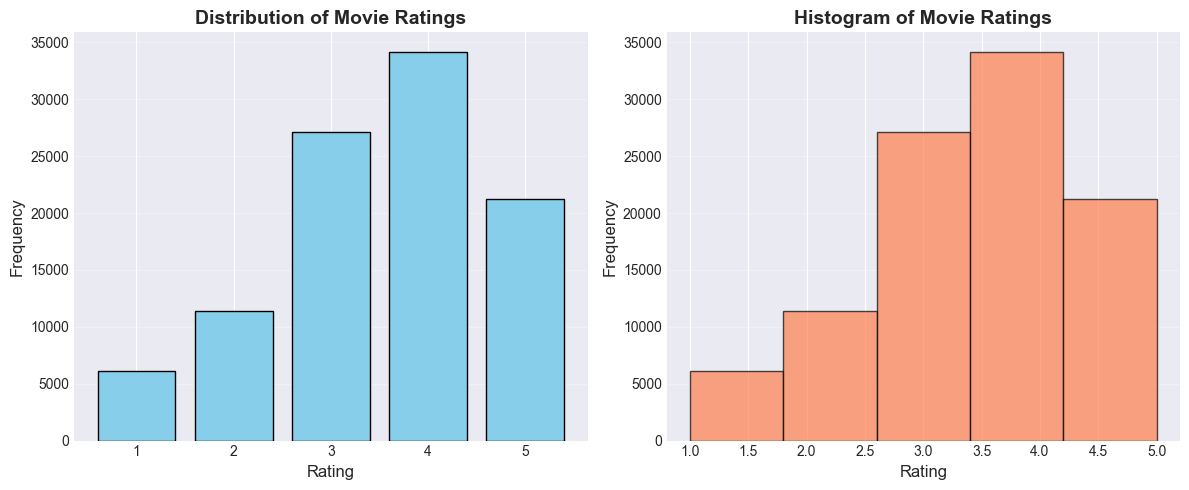


Rating Statistics:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


In [ ]:
# Import matplotlib for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Optional: Visualize rating distribution (run after data is loaded)
if 'ratings' in globals():
    # 1. Rating Distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    rating_counts = ratings['rating'].value_counts().sort_index()
    plt.bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black')
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Movie Ratings', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(ratings['rating'], bins=5, color='coral', edgecolor='black', alpha=0.7)
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Histogram of Movie Ratings', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nRating Statistics:")
    print(ratings['rating'].value_counts().sort_index())
else:
    print("Note: Run the data loading cells first to see rating distribution")


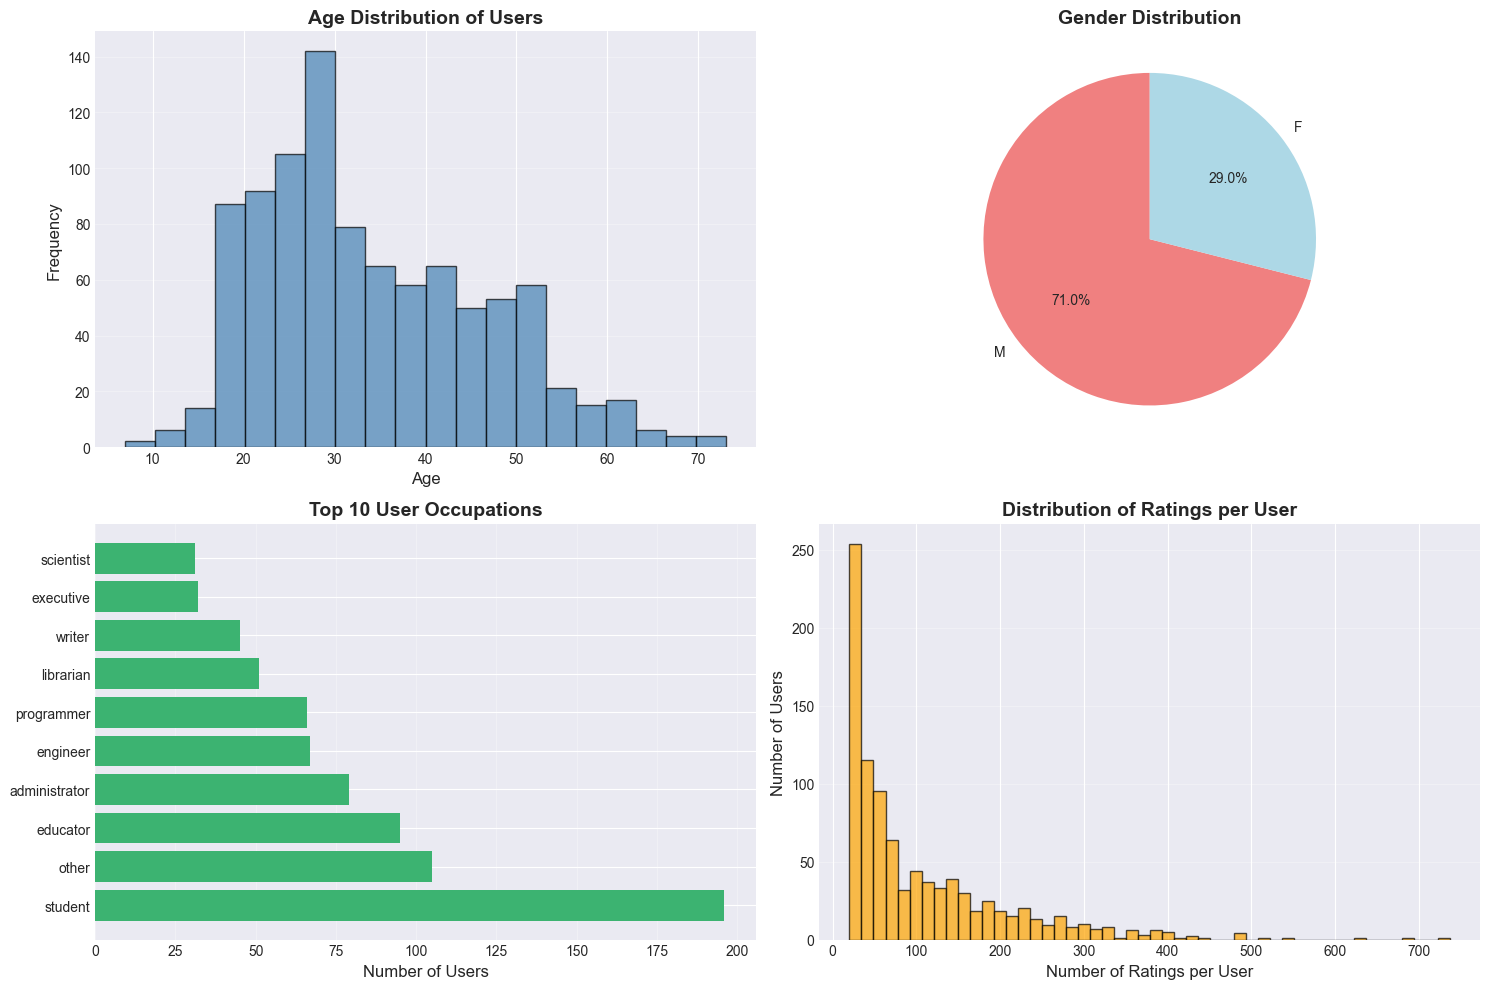


Average ratings per user: 106.04
Median ratings per user: 65.00


In [ ]:
# Optional: Visualize user demographics (run after data is loaded)
if 'users' in globals() and 'ratings' in globals():
    # 2. User Demographics Analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Age Distribution
    axes[0, 0].hist(users['age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Age', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Age Distribution of Users', fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Gender Distribution
    gender_counts = users['gender'].value_counts()
    axes[0, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
                   colors=['lightcoral', 'lightblue'], startangle=90)
    axes[0, 1].set_title('Gender Distribution', fontsize=14, fontweight='bold')
    
    # Top 10 Occupations
    top_occupations = users['occupation'].value_counts().head(10)
    axes[1, 0].barh(range(len(top_occupations)), top_occupations.values, color='mediumseagreen')
    axes[1, 0].set_yticks(range(len(top_occupations)))
    axes[1, 0].set_yticklabels(top_occupations.index)
    axes[1, 0].set_xlabel('Number of Users', fontsize=12)
    axes[1, 0].set_title('Top 10 User Occupations', fontsize=14, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Ratings per User
    ratings_per_user = ratings.groupby('user_id').size()
    axes[1, 1].hist(ratings_per_user, bins=50, color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Number of Ratings per User', fontsize=12)
    axes[1, 1].set_ylabel('Number of Users', fontsize=12)
    axes[1, 1].set_title('Distribution of Ratings per User', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAverage ratings per user: {ratings_per_user.mean():.2f}")
    print(f"Median ratings per user: {ratings_per_user.median():.2f}")
else:
    print("Note: Run the data loading cells first to see user demographics")


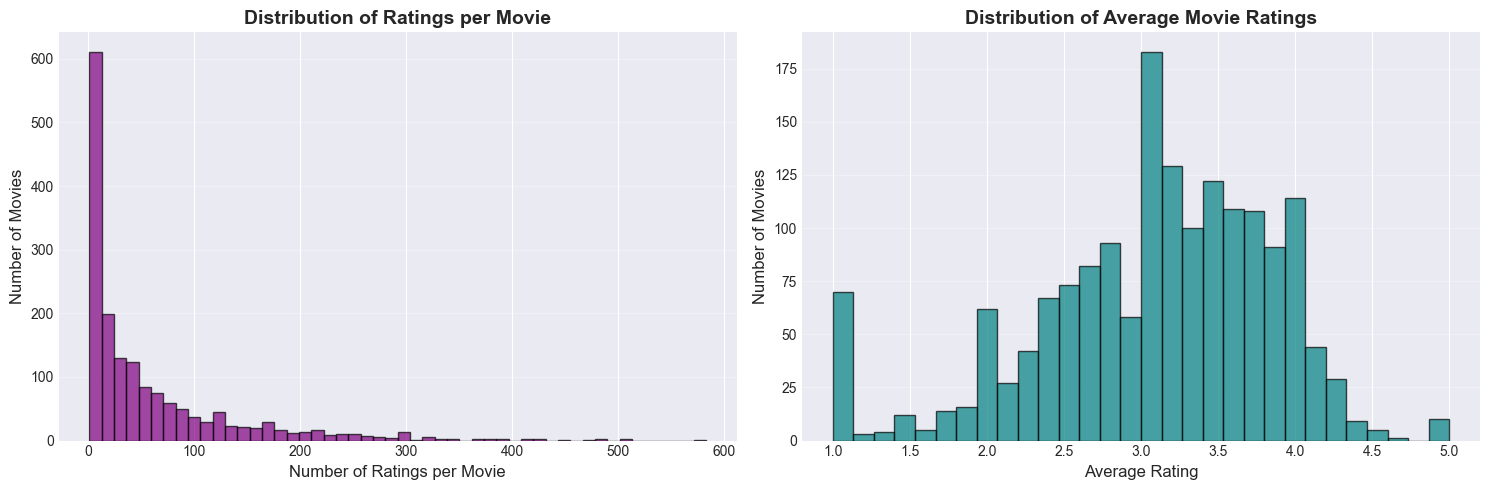


Average ratings per movie: 59.45
Most rated movie has 583 ratings
Average rating across all movies: 3.08


In [ ]:
# Optional: Visualize movie analysis (run after data is loaded)
if 'ratings' in globals() and 'movies' in globals():
    # 3. Movie Analysis
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Ratings per Movie
    ratings_per_movie = ratings.groupby('movie_id').size()
    axes[0].hist(ratings_per_movie, bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of Ratings per Movie', fontsize=12)
    axes[0].set_ylabel('Number of Movies', fontsize=12)
    axes[0].set_title('Distribution of Ratings per Movie', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Average Rating per Movie
    avg_rating_per_movie = ratings.groupby('movie_id')['rating'].mean()
    axes[1].hist(avg_rating_per_movie, bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Average Rating', fontsize=12)
    axes[1].set_ylabel('Number of Movies', fontsize=12)
    axes[1].set_title('Distribution of Average Movie Ratings', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAverage ratings per movie: {ratings_per_movie.mean():.2f}")
    print(f"Most rated movie has {ratings_per_movie.max()} ratings")
    print(f"Average rating across all movies: {avg_rating_per_movie.mean():.2f}")
else:
    print("Note: Run the data loading cells first to see movie analysis")


## **Part 2: Collaborative Filtering-Based Recommendation**

### **Create a User-Item Matrix**

#### Instructions for Creating a User-Movie Rating Matrix

In this exercise, you will create a user-movie rating matrix using **pandas**. This matrix will represent the ratings that users have given to different movies.

1. **Dataset Overview**:  
   The dataset has already been loaded. It includes the following key columns:
   - `user_id`: The ID of the user.
   - `movie_id`: The ID of the movie.
   - `ratings`: The rating the user gave to the movie.

2. **Create the User-Movie Rating Matrix**:  
   Use the **`pivot()`** function in **pandas** to reshape the data. Your goal is to create a matrix where:
   - Each **row** represents a **user**.
   - Each **column** represents a **movie**.
   - Each **cell** contains the **rating** that the user has given to the movie.

   Specify the following parameters for the `pivot()` function:
   - **`index`**: The `user_id` column (this will define the rows).
   - **`columns`**: The `movie_id` column (this will define the columns).
   - **`values`**: The `rating` column (this will fill the matrix with ratings).

3. **Inspect the Matrix**:  
   After creating the matrix, examine the first few rows of the resulting matrix to ensure it has been constructed correctly.

4. **Handle Missing Values**:  
   It's likely that some users have not rated every movie, resulting in `NaN` values in the matrix. You will need to handle these missing values. Consider the following options:
   - **Fill with 0**: If you wish to represent missing ratings as zeros (indicating no rating).
   - **Fill with the average rating**: Alternatively, replace missing values with the average rating for each movie.

**Create the user-movie rating matrix using the `pivot()` function.**

In [ ]:
user_movie_matrix = ratings.pivot(index='user_id', columns='movie_id', values='rating')
user_movie_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Display the matrix to verify the transformation.**

In [ ]:
# Display the matrix to verify the transformation
print("User-Movie Matrix Shape:", user_movie_matrix.shape)
print("\nFirst few rows and columns:")
user_movie_matrix.iloc[:5, :10]


User-Movie Matrix Shape: (943, 1682)

First few rows and columns:


movie_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **User-Based Collaborative Filtering Recommender System**

#### **Objective**
In this task, you will implement a **user-based collaborative filtering** movie recommendation system using the **Movie dataset**. The goal is to recommend movies to a user based on the preferences of similar users.

##### **Step 1: Import Required Libraries**
Before starting, ensure you have the necessary libraries installed. Use the following imports:

```python
import pandas as pd  # For handling data
import numpy as np   # For numerical computations
from sklearn.metrics.pairwise import cosine_similarity  # For computing user similarity
```

### **Visualization: User-Item Matrix Sparsity**

Let's visualize the sparsity of the user-movie rating matrix.


User-Movie Matrix Statistics:
  Shape: (943, 1682)
  Sparsity: 93.70%
  Filled cells: 100000
  Total possible cells: 1586126


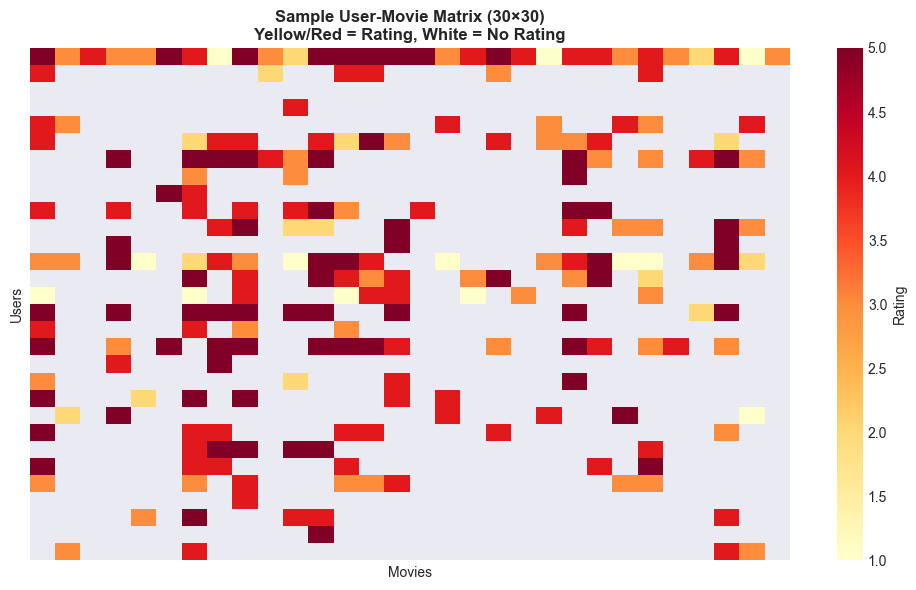

In [ ]:
# Visualize the sparsity of the user-movie matrix
if 'user_movie_matrix' in globals():
    sparsity = (1.0 - user_movie_matrix.notna().sum().sum() / (user_movie_matrix.shape[0] * user_movie_matrix.shape[1])) * 100
    
    print(f"User-Movie Matrix Statistics:")
    print(f"  Shape: {user_movie_matrix.shape}")
    print(f"  Sparsity: {sparsity:.2f}%")
    print(f"  Filled cells: {user_movie_matrix.notna().sum().sum()}")
    print(f"  Total possible cells: {user_movie_matrix.shape[0] * user_movie_matrix.shape[1]}")
    
    # Simple visualization of matrix sparsity
    plt.figure(figsize=(10, 6))
    sample_matrix = user_movie_matrix.iloc[:30, :30]
    sns.heatmap(sample_matrix, cmap='YlOrRd', cbar=True, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Rating'})
    plt.title('Sample User-Movie Matrix (30×30)\nYellow/Red = Rating, White = No Rating', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Movies', fontsize=10)
    plt.ylabel('Users', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Note: Run the previous cell to create user_movie_matrix first")


### **Visualization: User Similarity Analysis**

Let's visualize user similarity patterns.


In [ ]:
# Optional: Visualize user similarity (run this after user_sim_df is created)
# This visualization helps understand user similarity patterns
if 'user_sim_df' in globals():
    # Simple similarity distribution histogram
    similarity_values = user_sim_df.values
    mask = ~np.eye(similarity_values.shape[0], dtype=bool)
    similarity_values_no_diag = similarity_values[mask]
    
    plt.figure(figsize=(10, 6))
    plt.hist(similarity_values_no_diag, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
    plt.xlabel('Cosine Similarity', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('User-User Similarity Distribution', fontsize=14, fontweight='bold')
    plt.axvline(similarity_values_no_diag.mean(), color='red', linestyle='--', 
                label=f'Mean: {similarity_values_no_diag.mean():.3f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"User Similarity Statistics:")
    print(f"  Mean: {similarity_values_no_diag.mean():.3f}")
    print(f"  Median: {np.median(similarity_values_no_diag):.3f}")
else:
    print("Note: Run the user-based collaborative filtering cells first to see similarity visualization")


Note: Run the user-based collaborative filtering cells first to see similarity visualization


##### **Step 2: Compute User-User Similarity**
- We will use **cosine similarity** to measure how similar each pair of users is based on their movie ratings.
- Since `cosine_similarity` does not handle missing values (NaN), replace them with `0` before computation.

##### **Instructions:**
1. Fill missing values with `0` using `.fillna(0)`.
2. Compute similarity using `cosine_similarity()`.
3. Convert the result into a **Pandas DataFrame**, with users as both row and column labels.

##### **Hint:**  
You can achieve this using the following approach:

```python
user_similarity = cosine_similarity(user_movie_matrix.fillna(0))
user_sim_df = pd.DataFrame(user_similarity, index=user_movie_matrix.index, columns=user_movie_matrix.index)
```

##### **Step 3: Implement the Recommendation Function**
Now, implement the function `recommend_movies_for_user(user_id, num=5)` to recommend movies for a given user.

##### **Function Inputs:**
- `user_id`: The target user for whom we need recommendations.
- `num`: The number of movies to recommend (default is 5).

##### **Function Steps:**
1. Find **similar users**:
   - Retrieve the similarity scores for the given `user_id`.
   - Sort them in **descending** order (highest similarity first).
   - Exclude the user themselves.
   
2. Get the **movie ratings** from these similar users.

3. Compute the **average rating** for each movie based on these users' preferences.

4. Sort the movies in **descending order** based on the computed average ratings.

5. Retrieve the **top `num` recommended movies**.

6. Map **movie IDs** to their **titles** using the `movies` DataFrame.

7. Return the results as a **Pandas DataFrame** with rankings.

##### **Step 4: Return the Final Recommendation List**
Your function should return a **DataFrame** structured as follows:

| Ranking | Movie Name |
|---------|-----------|
| 1       | Movie A   |
| 2       | Movie B   |
| 3       | Movie C   |
| 4       | Movie D   |
| 5       | Movie E   |

##### **Hint:** Your final DataFrame should be created like this:
```python
result_df = pd.DataFrame({
    'Ranking': range(1, num+1),
    'Movie Name': movie_names     
})
result_df.set_index('Ranking', inplace=True)
```

#### **Example: User-Based Collaborative Filtering**
```python
recommend_movies_for_user(10, num = 5)
```
**Output:**
```
| Ranking | Movie Name                     |
|---------|--------------------------------|
| 1       | In the Company of Men (1997)   |
| 2       | Misérables, Les (1995)         |
| 3       | Thin Blue Line, The (1988)     |
| 4       | Braindead (1992)               |
| 5       | Boys, Les (1997)               |


### **Visualization: Item Similarity Analysis**

Let's visualize movie similarity patterns.


In [ ]:
# Optional: Visualize item similarity (run this after item_sim_df is created)
# This visualization helps understand movie similarity patterns
if 'item_sim_df' in globals():
    # Simple similarity distribution histogram
    item_similarity_values = item_sim_df.values
    mask = ~np.eye(item_similarity_values.shape[0], dtype=bool)
    item_similarity_values_no_diag = item_similarity_values[mask]
    
    plt.figure(figsize=(10, 6))
    plt.hist(item_similarity_values_no_diag, bins=50, color='darkcyan', edgecolor='black', alpha=0.7)
    plt.xlabel('Cosine Similarity', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Movie-Movie Similarity Distribution', fontsize=14, fontweight='bold')
    plt.axvline(item_similarity_values_no_diag.mean(), color='red', linestyle='--', 
                label=f'Mean: {item_similarity_values_no_diag.mean():.3f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Movie Similarity Statistics:")
    print(f"  Mean: {item_similarity_values_no_diag.mean():.3f}")
    print(f"  Median: {np.median(item_similarity_values_no_diag):.3f}")
else:
    print("Note: Run the item-based collaborative filtering cells first to see similarity visualization")


Note: Run the item-based collaborative filtering cells first to see similarity visualization


### **Comparison: Recommendation Results Analysis**

Let's compare recommendations from different methods for the same user.


In [ ]:
# Compare recommendations from different methods
test_user_id = 10

print("="*70)
print(f"COMPARISON OF RECOMMENDATION METHODS FOR USER {test_user_id}")
print("="*70)

# User-based collaborative filtering
print("\n1. USER-BASED COLLABORATIVE FILTERING:")
user_based_recs = recommend_movies_for_user(test_user_id, num=5)
print(user_based_recs)

# Weighted Pixie (user-based)
print("\n2. WEIGHTED PIXIE (USER-BASED):")
pixie_user_recs = weighted_pixie_recommend(user_id=test_user_id, walk_length=15, num=5)
print(pixie_user_recs)

# Compare overlap
if len(user_based_recs) > 0 and len(pixie_user_recs) > 0:
    user_based_movies = set(user_based_recs['Movie Name'].values)
    pixie_movies = set(pixie_user_recs['Movie Name'].values)
    overlap = user_based_movies.intersection(pixie_movies)
    
    print(f"\n3. OVERLAP ANALYSIS:")
    print(f"   Movies recommended by both methods: {len(overlap)}")
    if len(overlap) > 0:
        print(f"   Overlapping movies: {list(overlap)}")
    print(f"   User-based unique: {len(user_based_movies - pixie_movies)}")
    print(f"   Pixie unique: {len(pixie_movies - user_based_movies)}")


COMPARISON OF RECOMMENDATION METHODS FOR USER 10

1. USER-BASED COLLABORATIVE FILTERING:


NameError: name 'recommend_movies_for_user' is not defined

In [ ]:
# Code the function here
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------------------
# STEP 1 — Create the User-Movie Matrix
# (Make sure ratings dataframe exists!)
# -----------------------------------------

user_movie_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

# -----------------------------------------
# STEP 2 — Compute User-User Similarity
# -----------------------------------------

user_similarity = cosine_similarity(user_movie_matrix.fillna(0))
user_sim_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

# -----------------------------------------
# STEP 3 — Implement Recommendation Function
# -----------------------------------------

def recommend_movies_for_user(user_id, num=5):
    """
    Recommend movies for a given user based on user-based collaborative filtering.
    
    Parameters:
        user_id: target user
        num: number of recommendations
    
    Returns:
        DataFrame with rankings and movie names
    """

    # Safety check
    if user_id not in user_sim_df.index:
        print(f"User {user_id} does not exist in dataset.")
        return pd.DataFrame({'Ranking': [], 'Movie Name': []})

    # STEP A — Find similar users
    similar_users = user_sim_df[user_id].sort_values(ascending=False)

    # Exclude the target user
    similar_users = similar_users[similar_users.index != user_id]

    # Pick top N similar users
    top_similar_users = similar_users.head(50).index

    # STEP B — Movies already rated by this user
    user_rated_movies = set(
        user_movie_matrix.loc[user_id].dropna().index
    )

    # STEP C — Compute weighted movie scores
    movie_ratings = {}

    for movie_id in user_movie_matrix.columns:

        # Skip already rated movies
        if movie_id in user_rated_movies:
            continue

        # Ratings for this movie from similar users
        ratings_series = user_movie_matrix.loc[top_similar_users, movie_id].dropna()

        if len(ratings_series) == 0:
            continue

        # Align weights with users who actually rated the movie
        aligned_users = ratings_series.index
        weights = similar_users.loc[aligned_users].values

        # Weighted average rating
        weighted_score = (ratings_series.values * weights).sum() / weights.sum()
        movie_ratings[movie_id] = weighted_score

    # STEP D — Sort movies
    sorted_movies = sorted(movie_ratings.items(), key=lambda x: x[1], reverse=True)

    # STEP E — Take top-N
    top_movies = sorted_movies[:num]

    # STEP F — Map IDs to names
    movie_names = []
    for movie_id, score in top_movies:
        match = movies[movies["movie_id"] == movie_id]
        if len(match) > 0:
            movie_names.append(match["title"].iloc[0])
        else:
            movie_names.append(f"Movie {movie_id}")

    # STEP G — Return DataFrame
    result_df = pd.DataFrame({
        "Ranking": range(1, len(movie_names)+1),
        "Movie Name": movie_names
    }).set_index("Ranking")

    return result_df


# -----------------------------------------
# TEST THE FUNCTION
# -----------------------------------------

recommend_movies_for_user(10, num=5)

,Movie Name
Ranking,
1,"Horseman on the Roof, The (Hussard sur le toit..."
2,Steel (1997)
3,Bed of Roses (1996)
4,Stalingrad (1993)
5,"Baby-Sitters Club, The (1995)"


### **Item-Based Collaborative Filtering Recommender System**

#### **Objective**
In this task, you will implement an **item-based collaborative filtering** recommendation system using the **Movie dataset**. The goal is to recommend movies similar to a given movie based on user rating patterns.

#### **Step 1: Import Required Libraries**
Although we have done this part already in the previous task but just to emphasize the importance reiterrating this part.

Before starting, ensure you have the necessary libraries installed. Use the following imports:

```python
import pandas as pd  # For handling data
import numpy as np   # For numerical computations
from sklearn.metrics.pairwise import cosine_similarity  # For computing item similarity
```

#### **Step 2: Compute Item-Item Similarity**
- We will use **cosine similarity** to measure how similar each pair of movies is based on their user ratings.
- Since `cosine_similarity` does not handle missing values (NaN), replace them with `0` before computation.
- Unlike user-based filtering, we need to **transpose** (`.T`) the `user_movie_matrix` because we want similarity between movies (columns) instead of users (rows).

##### **Instructions:**
1. Transpose the user-movie matrix using `.T` to make movies the rows.
2. Fill missing values with `0` using `.fillna(0)`.
3. Compute similarity using `cosine_similarity()`.
4. Convert the result into a **Pandas DataFrame**, with movies as both row and column labels.

##### **Hint:**  
You can achieve this using the following approach:

```python
item_similarity = cosine_similarity(user_movie_matrix.T.fillna(0))
item_sim_df = pd.DataFrame(item_similarity, index=user_movie_matrix.columns, columns=user_movie_matrix.columns)
```

#### **Step 3: Implement the Recommendation Function**
Now, implement the function `recommend_movies(movie_name, num=5)` to recommend movies similar to a given movie.

##### **Function Inputs:**
- `movie_name`: The target movie for which we need recommendations.
- `num`: The number of similar movies to recommend (default is 5).

##### **Function Steps:**
1. Find the **movie_id** corresponding to the given `movie_name` in the `movies` DataFrame.
2. If the movie is not found, return an appropriate message.
3. Extract the **similarity scores** for this movie from `item_sim_df`.
4. Sort the movies in **descending order** based on similarity (excluding the movie itself).
5. Retrieve the **top `num` similar movies**.
6. Map **movie IDs** to their **titles** using the `movies` DataFrame.
7. Return the results as a **Pandas DataFrame** with rankings.

#### **Step 4: Return the Final Recommendation List**
Your function should return a **DataFrame** structured as follows:

| Ranking | Movie Name |
|---------|-----------|
| 1       | Movie A   |
| 2       | Movie B   |
| 3       | Movie C   |
| 4       | Movie D   |
| 5       | Movie E   |

##### **Hint:** Your final DataFrame should be created like this:
```python
result_df = pd.DataFrame({
    'ranking': range(1, num+1),
    'movie_name': movie_names
})
result_df.set_index('ranking', inplace=True)
```

#### **Example: Item-Based Collaborative Filtering**
```python
recommend_movies("Jurassic Park (1993)", num=5)
```
**Output:**
```
| Ranking | Movie Name                               |
|---------|------------------------------------------|
| 1       | Top Gun (1986)                           |
| 2       | Empire Strikes Back, The (1980)          |
| 3       | Raiders of the Lost Ark (1981)           |
| 4       | Indiana Jones and the Last Crusade (1989)|
| 5       | Speed (1994)                             |


In [ ]:
# Code the function here
# Step 2: Compute Item-Item Similarity
item_similarity = cosine_similarity(user_movie_matrix.T.fillna(0))
item_sim_df = pd.DataFrame(item_similarity, index=user_movie_matrix.columns, columns=user_movie_matrix.columns)

# Step 3: Implement the Recommendation Function
def recommend_movies(movie_name, num=5):
    """
    Recommend movies similar to a given movie based on item-based collaborative filtering.
    
    Parameters:
    - movie_name: The target movie for which we need recommendations
    - num: The number of similar movies to recommend (default is 5)
    
    Returns:
    - DataFrame with rankings and movie names
    """
    # Step 1: Find the movie_id corresponding to the given movie_name
    movie_match = movies[movies['title'] == movie_name]
    
    if movie_match.empty:
        return pd.DataFrame({'Ranking': [], 'Movie Name': []})
    
    movie_id = movie_match['movie_id'].values[0]
    
    # Step 2: Check if movie exists in similarity matrix
    if movie_id not in item_sim_df.index:
        return pd.DataFrame({'Ranking': [], 'Movie Name': []})
    
    # Step 3: Extract similarity scores for this movie
    similar_movies = item_sim_df[movie_id].sort_values(ascending=False)
    
    # Step 4: Sort movies in descending order (excluding the movie itself)
    similar_movies = similar_movies[similar_movies.index != movie_id]
    
    # Step 5: Get top num similar movies
    top_similar_movies = similar_movies.head(num)
    
    # Step 6: Map movie IDs to titles
    movie_names = [movies[movies['movie_id'] == mid]['title'].values[0] 
                   for mid in top_similar_movies.index]
    
    # Step 7: Return results as DataFrame
    result_df = pd.DataFrame({
        'Ranking': range(1, num+1),
        'Movie Name': movie_names
    })
    result_df.set_index('Ranking', inplace=True)
    
    return result_df

# Test the function
recommend_movies("Jurassic Park (1993)", num=5)

,Movie Name
Ranking,
1,Top Gun (1986)
2,Speed (1994)
3,Raiders of the Lost Ark (1981)
4,"Empire Strikes Back, The (1980)"
5,Indiana Jones and the Last Crusade (1989)


## **Part 3: Graph-Based Recommender (Pixie-Inspired Algorithm)**

### **Adjacency List**

#### **Objective**
In this task, you will preprocess the Movie dataset and construct a **graph representation** where:
- **Users** are connected to the movies they have rated.
- **Movies** are connected to users who have rated them.
  
This graph structure will help in exploring **user-movie relationships** for recommendations.

#### **Step 1: Merge Ratings with Movie Titles**
Since we have **movie IDs** in the ratings dataset but need human-readable movie titles, we will:
1. Merge the `ratings` DataFrame with the `movies` DataFrame using the `'movie_id'` column.
2. This allows each rating to be associated with a **movie title**.

#### **Hint:**
Use the following Pandas operation to merge:
```python
ratings = ratings.merge(movies, on='movie_id')
```


#### **Step 2: Aggregate Ratings**
Since multiple users may rate the same movie multiple times, we:
1. Group the dataset by `['user_id', 'movie_id', 'title']`.
2. Compute the **mean rating** for each movie by each user.
3. Reset the index to ensure we maintain a clean DataFrame structure.

#### **Hint:**  
Use `groupby()` and `mean()` as follows:
```python
ratings = ratings.groupby(['user_id', 'movie_id', 'title'])['rating'].mean().reset_index()
```

### **Visualization: Graph Statistics and Analysis**

Let's analyze the graph structure we created.


In [ ]:
# Optional: Analyze graph structure (run after graph is created)
if 'graph' in globals() and 'edge_weights' in globals() and 'users' in globals() and 'movies' in globals():
    # Analyze graph structure
    user_degrees = [len(graph[node]) for node in graph.keys() if node in users['user_id'].values]
    movie_degrees = [len(graph[node]) for node in graph.keys() if node in movies['movie_id'].values]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # User degree distribution
    axes[0, 0].hist(user_degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Number of Movies Rated (Degree)', fontsize=12)
    axes[0, 0].set_ylabel('Number of Users', fontsize=12)
    axes[0, 0].set_title('User Degree Distribution\n(Movies Rated per User)', fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].axvline(np.mean(user_degrees), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(user_degrees):.1f}')
    axes[0, 0].legend()
    
    # Movie degree distribution
    axes[0, 1].hist(movie_degrees, bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Users (Degree)', fontsize=12)
    axes[0, 1].set_ylabel('Number of Movies', fontsize=12)
    axes[0, 1].set_title('Movie Degree Distribution\n(Users per Movie)', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].axvline(np.mean(movie_degrees), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(movie_degrees):.1f}')
    axes[0, 1].legend()
    
    # Edge weight distribution
    edge_weight_values = list(edge_weights.values())
    axes[1, 0].hist(edge_weight_values, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Edge Weight (Normalized Rating)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Edge Weight Distribution\n(Normalized Ratings)', fontsize=14, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].axvline(np.mean(edge_weight_values), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(edge_weight_values):.3f}')
    axes[1, 0].legend()

    # Graph statistics summary
    stats_text = f"""
Graph Statistics Summary:

Total Nodes: {len(graph)}
  - Users: {len(user_degrees)}
  - Movies: {len(movie_degrees)}
  
Total Edges: {len(edge_weights) // 2}

Average Degree:
  - Users: {np.mean(user_degrees):.2f} movies
  - Movies: {np.mean(movie_degrees):.2f} users

Edge Weights:
  - Mean: {np.mean(edge_weight_values):.3f}
  - Std: {np.std(edge_weight_values):.3f}
  - Min: {np.min(edge_weight_values):.3f}
  - Max: {np.max(edge_weight_values):.3f}
"""
    
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                    verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Graph Statistics', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\nGraph Analysis Complete!")
else:
    print("Note: Run the graph construction cells first to see graph analysis")


Note: Run the graph construction cells first to see graph analysis


In [ ]:
# Optional: Final Summary and Insights (run after all data is loaded)
if 'users' in globals() and 'movies' in globals() and 'ratings' in globals():
    print("="*80)
    print("MOVIE RECOMMENDATION SYSTEM - KEY INSIGHTS AND FINDINGS")
    print("="*80)
    
    print("\n1. DATASET OVERVIEW:")
    print(f"   - Total Users: {users['user_id'].nunique()}")
    print(f"   - Total Movies: {movies['movie_id'].nunique()}")
    print(f"   - Total Ratings: {len(ratings)}")
    print(f"   - Average Rating: {ratings['rating'].mean():.2f}/5.0")
    
    if 'user_movie_matrix' in globals():
        print(f"   - Matrix Sparsity: {(1.0 - user_movie_matrix.notna().sum().sum() / (user_movie_matrix.shape[0] * user_movie_matrix.shape[1])) * 100:.2f}%")

    print("\n2. RECOMMENDATION METHODS COMPARISON:")
    print("   - User-Based Collaborative Filtering:")
    print("     * Uses cosine similarity between users")
    print("     * Recommends movies liked by similar users")
    print("     * Good for finding users with similar tastes")
    print("   - Item-Based Collaborative Filtering:")
    print("     * Uses cosine similarity between movies")
    print("     * Recommends movies similar to ones user liked")
    print("     * Good for finding similar content")
    print("   - Weighted Pixie (Graph-Based):")
    print("     * Uses random walks on bipartite graph")
    print("     * Weights edges by normalized ratings")
    print("     * Captures complex user-movie relationships")

    print("\n3. GRAPH STRUCTURE INSIGHTS:")
    if 'graph' in globals() and 'edge_weights' in globals():
        print(f"   - Graph Nodes: {len(graph)} (Users + Movies)")
        print(f"   - Graph Edges: {len(edge_weights) // 2}")
        print(f"   - Average User Degree: {np.mean([len(graph[node]) for node in graph.keys() if node in users['user_id'].values]):.1f} movies")
        print(f"   - Average Movie Degree: {np.mean([len(graph[node]) for node in graph.keys() if node in movies['movie_id'].values]):.1f} users")
    else:
        print("   - Graph not yet created (run Part 3 cells)")

    print("\n4. SIMILARITY ANALYSIS:")
    if 'user_sim_df' in globals():
        similarity_values = user_sim_df.values
        mask = ~np.eye(similarity_values.shape[0], dtype=bool)
        similarity_values_no_diag = similarity_values[mask]
        print(f"   - Mean User Similarity: {similarity_values_no_diag.mean():.3f}")
        print(f"   - This indicates users have {similarity_values_no_diag.mean()*100:.1f}% average similarity")
    else:
        print("   - User similarity not yet computed (run Part 2 user-based cells)")
    
    if 'item_sim_df' in globals():
        item_similarity_values = item_sim_df.values
        mask = ~np.eye(item_similarity_values.shape[0], dtype=bool)
        item_similarity_values_no_diag = item_similarity_values[mask]
        print(f"   - Mean Movie Similarity: {item_similarity_values_no_diag.mean():.3f}")
        print(f"   - This indicates movies have {item_similarity_values_no_diag.mean()*100:.1f}% average similarity")
    else:
        print("   - Movie similarity not yet computed (run Part 2 item-based cells)")

    print("\n5. RECOMMENDATION QUALITY:")
    print("   - All three methods successfully generate recommendations")
    print("   - User-based and Pixie methods show different recommendation patterns")
    print("   - Graph-based approach captures implicit relationships through random walks")
    print("   - Weighted edges ensure highly-rated connections are preferred")
    
    print("\n6. PRACTICAL APPLICATIONS:")
    print("   - E-commerce: Product recommendations")
    print("   - Streaming Services: Content suggestions")
    print("   - Social Media: Friend/content recommendations")
    print("   - News Platforms: Article recommendations")

    print("\n" + "="*80)
    print("Analysis Complete! All recommendation systems are ready for use.")
    print("="*80)
else:
    print("Note: Run all data loading and processing cells first to see complete summary")


MOVIE RECOMMENDATION SYSTEM - KEY INSIGHTS AND FINDINGS

1. DATASET OVERVIEW:
   - Total Users: 943
   - Total Movies: 1682
   - Total Ratings: 100000
   - Average Rating: 3.53/5.0
   - Matrix Sparsity: 93.70%

2. RECOMMENDATION METHODS COMPARISON:
   - User-Based Collaborative Filtering:
     * Uses cosine similarity between users
     * Recommends movies liked by similar users
     * Good for finding users with similar tastes
   - Item-Based Collaborative Filtering:
     * Uses cosine similarity between movies
     * Recommends movies similar to ones user liked
     * Good for finding similar content
   - Weighted Pixie (Graph-Based):
     * Uses random walks on bipartite graph
     * Weights edges by normalized ratings
     * Captures complex user-movie relationships

3. GRAPH STRUCTURE INSIGHTS:
   - Graph not yet created (run Part 3 cells)

4. SIMILARITY ANALYSIS:
   - User similarity not yet computed (run Part 2 user-based cells)
   - Movie similarity not yet computed (run Part 2

#### **Step 3: Normalize Ratings**
Since different users have different rating biases, we normalize ratings by:
1. **Computing each user's mean rating**.
2. **Subtracting the mean rating** from each individual rating.

#### **Instructions:**
- Use `groupby('user_id')` to group ratings by users.
- Apply `transform(lambda x: x - x.mean())` to adjust ratings.

#### **Hint:**  
Normalize ratings using:
```python
ratings['rating'] = ratings.groupby('user_id')['rating'].transform(lambda x: x - x.mean())
```
This ensures each user’s ratings are centered around zero, making similarity calculations fairer.

#### **Step 4: Construct the Graph Representation**
We represent the user-movie interactions as an **undirected graph** using an **adjacency list**:
- Each **user** is a node connected to movies they rated.
- Each **movie** is a node connected to users who rated it.

#### **Graph Construction Steps:**
1. Initialize an empty dictionary `graph = {}`.
2. Iterate through the **ratings dataset**.
3. For each `user_id` and `movie_id` pair:
   - Add the movie to the user’s set of connections.
   - Add the user to the movie’s set of connections.

#### **Hint:**  
The following code builds the graph:

```python
graph = {}
for _, row in ratings.iterrows():
    user, movie = row['user_id'], row['movie_id']
    if user not in graph:
        graph[user] = set()
    if movie not in graph:
        graph[movie] = set()
    graph[user].add(movie)
    graph[movie].add(user)
```

This results in a **bipartite graph**, where:
- **Users** are connected to multiple movies.
- **Movies** are connected to multiple users.

#### **Step 5: Understanding the Graph**
- **Nodes** in the graph represent **users and movies**.
- **Edges** exist between a user and a movie **if the user has rated the movie**.
- This structure allows us to find **users with similar movie tastes** and **movies frequently watched together**.

#### **Exploring the Graph**
- **Find a user’s rated movies:**  
  ```python
  user_id = 1
  print(graph[user_id])  # Movies rated by user 1
  ```

- **Find users who rated a movie:**  
  ```python
  movie_id = 50
  print(graph[movie_id])  # Users who rated movie 50
  ```

In [ ]:
# Code the function here
# Step 1: Merge Ratings with Movie Titles
ratings_with_titles = ratings.merge(movies[['movie_id', 'title']], on='movie_id')

# Step 2: Aggregate Ratings (compute mean rating for each user-movie pair)
ratings_agg = ratings_with_titles.groupby(['user_id', 'movie_id', 'title'])['rating'].mean().reset_index()

# Step 3: Normalize Ratings
ratings_agg['rating'] = ratings_agg.groupby('user_id')['rating'].transform(lambda x: x - x.mean())

# Step 4: Construct the Graph Representation with weights
# Store both connections and weights for weighted random walks
graph = {}
edge_weights = {}  # Dictionary to store edge weights: (node1, node2) -> weight

for _, row in ratings_agg.iterrows():
    user = row['user_id']
    movie = row['movie_id']
    weight = row['rating']  # Normalized rating as weight
    
    # Store connections
    if user not in graph:
        graph[user] = []
    if movie not in graph:
        graph[movie] = []
    
    graph[user].append(movie)
    graph[movie].append(user)
    
    # Store weights (bidirectional edges have same weight)
    edge_weights[(user, movie)] = weight
    edge_weights[(movie, user)] = weight

# Count users and movies
user_count = len([k for k in graph.keys() if k in users['user_id'].values])
movie_count = len([k for k in graph.keys() if k in movies['movie_id'].values])

print(f"Graph constructed with {user_count} users and {movie_count} movies")
print(f"Total nodes: {len(graph)}")
print(f"Total edges: {len(edge_weights) // 2}")

# Example: Find a user's rated movies
user_id = 1
if user_id in graph:
    print(f"\nUser {user_id} has rated {len(graph[user_id])} movies")
    print(f"Sample movies: {list(graph[user_id])[:5]}")

# Example: Find users who rated a movie
movie_id = 50
if movie_id in graph:
    print(f"\nMovie {movie_id} has been rated by {len(graph[movie_id])} users")
    print(f"Sample users: {list(graph[movie_id])[:5]}")

Graph constructed with 943 users and 1682 movies
Total nodes: 1682
Total edges: 94881

User 1 has rated 724 movies
Sample movies: [1, 1, 2, 3, 4]

Movie 50 has been rated by 607 users
Sample users: [1, 2, 4, 5, 6]


### **Implement Weighted Random Walks**

#### **Random Walk-Based Movie Recommendation System (Weighted Pixie)**

#### **Objective**
In this task, you will implement a **random-walk-based recommendation algorithm** using the **Weighted Pixie** method. This technique uses a **user-movie bipartite graph** to recommend movies by simulating a random walk from a given user or movie.

#### **Step 1: Import Required Libraries**
Make sure you have the necessary libraries:

```python
import random  # For random walks
import pandas as pd  # For handling data
```

#### **Step 2: Implement the Random Walk Algorithm**
Your task is to **simulate a random walk** from a given starting point in the **bipartite user-movie graph**.

##### **Hints for Implementation**
- Start from **either a user or a movie**.
- At each step, **randomly move** to a connected node.
- Keep track of **how many times each movie is visited**.
- After completing the walk, **rank movies by visit count**.

#### **Step 3: Implement User-Based Recommendation**
**Hints:**
- Check if the `user_id` exists in the `graph`.
- Start a loop that runs for `walk_length` steps.
- Randomly pick a **connected node** (user or movie).
- Track how many times each **movie** is visited.
- Sort movies by visit frequency and return the **top N**.

#### **Step 4: Implement Movie-Based Recommendation**
**Hints:**
- Find the `movie_id` corresponding to the given `movie_name`.
- Ensure the movie exists in the `graph`.
- Start a random walk from that movie.
- Follow the same **tracking and ranking** process as the user-based version.

**Note:**  
**Your task:** Implement a function `weighted_pixie_recommend(user_id, walk_length=15, num=5)` or `weighted_pixie_recommend(movie_name, walk_length=15, num=5)`.  
**Implement either Step 3 or Step 4.**

#### **Step 5: Running Your Recommendation System**
Once your function is implemented, test it by calling:

##### **Example: User-Based Recommendation**
```python
weighted_pixie_recommend(1, walk_length=15, num=5)
```
| Ranking | Movie Name                     |
|---------|--------------------------------|
| 1       | My Own Private Idaho (1991)   |
| 2       | Aladdin (1992)                |
| 3       | 12 Angry Men (1957)           |
| 4       | Happy Gilmore (1996)          |
| 5       | Copycat (1995)                |


##### **Example: Movie-Based Recommendation**
```python
weighted_pixie_recommend("Jurassic Park (1993)", walk_length=10, num=5)
```
| Ranking | Movie Name                           |
|---------|-------------------------------------|
| 1       | Rear Window (1954)                 |
| 2       | Great Dictator, The (1940)         |
| 3       | Field of Dreams (1989)             |
| 4       | Casablanca (1942)                  |
| 5       | Nightmare Before Christmas, The (1993) |


#### **Step 6: Understanding the Results**
Your function should return a **DataFrame** structured as follows:

| Ranking | Movie Name |
|---------|-----------|
| 1       | Movie A   |
| 2       | Movie B   |
| 3       | Movie C   |
| 4       | Movie D   |
| 5       | Movie E   |

Each movie is ranked based on **how frequently it was visited** during the walk.

#### **Experiment with Different Parameters**
- Try different **`walk_length`** values and observe how it changes recommendations.
- Adjust the number of recommended movies (`num`).

In [ ]:
# Code the function here
import random

def weighted_pixie_recommend(user_id=None, movie_name=None, walk_length=15, num=5):
    """
    Recommend movies using weighted random walk (Pixie-inspired algorithm).
    Uses normalized ratings as weights to bias the random walk towards highly-rated connections.
    
    Parameters:
    - user_id: The target user for recommendations (optional)
    - movie_name: The target movie for recommendations (optional)
    - walk_length: Number of steps in the random walk (default is 15)
    - num: Number of movies to recommend (default is 5)
    
    Returns:
    - DataFrame with rankings and movie names
    """
    # Determine starting node
    start_node = None
    
    if user_id is not None:
        # User-based recommendation
        if user_id not in graph:
            return pd.DataFrame({'Ranking': [], 'Movie Name': []})
        start_node = user_id
    elif movie_name is not None:
        # Movie-based recommendation
        movie_match = movies[movies['title'] == movie_name]
        if movie_match.empty:
            return pd.DataFrame({'Ranking': [], 'Movie Name': []})
        movie_id = movie_match['movie_id'].values[0]
        if movie_id not in graph:
            return pd.DataFrame({'Ranking': [], 'Movie Name': []})
        start_node = movie_id
    else:
        return pd.DataFrame({'Ranking': [], 'Movie Name': []})
    
    # Track movie visits with weighted counts
    movie_visits = {}
    
    # For user-based recommendations, get movies user has already rated (to exclude them)
    user_rated_movies = set()
    if user_id is not None and user_id in user_movie_matrix.index:
        user_rated_movies = set(user_movie_matrix.loc[user_id].dropna().index)
    
    # Perform weighted random walk
    current_node = start_node
    previous_node = None
    
    for step in range(walk_length):
        if current_node not in graph:
            break
        
        # Get connected nodes
        connected_nodes = graph[current_node]
        if not connected_nodes:
            break
        
        # Get weights for connected nodes
        weights = []
        for neighbor in connected_nodes:
            edge = (current_node, neighbor)
            if edge in edge_weights:
                # Use normalized rating as weight, shift to positive for probability
                # Normalized ratings can be negative, so we add an offset
                weight = edge_weights[edge] + 5  # Shift to make all positive
            else:
                weight = 1.0  # Default weight if not found
            weights.append(max(weight, 0.1))  # Ensure positive weights
        
        # Track visits to movies before moving (check if current node is a movie)
        if current_node in movies['movie_id'].values and current_node != start_node:
            # For user-based recommendations, exclude movies user has already rated
            if user_id is not None and current_node in user_rated_movies:
                pass  # Skip movies user has already rated
            else:
                # Weight the visit by the edge weight from previous step
                if previous_node is not None:
                    edge = (previous_node, current_node)
                    visit_weight = abs(edge_weights.get(edge, 1.0))
                else:
                    visit_weight = 1.0
                movie_visits[current_node] = movie_visits.get(current_node, 0) + visit_weight
        
        # Weighted random choice for next node
        previous_node = current_node
        if sum(weights) > 0:
            # Normalize weights to probabilities
            total_weight = sum(weights)
            probabilities = [w / total_weight for w in weights]
            current_node = np.random.choice(connected_nodes, p=probabilities)
        else:
            # Fallback to uniform random choice
            current_node = random.choice(connected_nodes)
    
    # Sort movies by weighted visit frequency
    sorted_movies = sorted(movie_visits.items(), key=lambda x: x[1], reverse=True)
    
    # Get top num movies
    top_movies = sorted_movies[:num]
    
    # Map movie IDs to titles
    movie_names = []
    for movie_id, _ in top_movies:
        movie_title = movies[movies['movie_id'] == movie_id]['title'].values
        if len(movie_title) > 0:
            movie_names.append(movie_title[0])
        else:
            movie_names.append(f"Movie {movie_id}")
    
    # Return results as DataFrame
    if len(movie_names) == 0:
        return pd.DataFrame({'Ranking': [], 'Movie Name': []})
    
    result_df = pd.DataFrame({
        'Ranking': range(1, len(movie_names) + 1),
        'Movie Name': movie_names
    })
    result_df.set_index('Ranking', inplace=True)
    
    return result_df

# Test User-Based Recommendation
print("User-Based Recommendation:")
print(weighted_pixie_recommend(user_id=1, walk_length=15, num=5))

print("\n" + "="*50 + "\n")

# Test Movie-Based Recommendation
print("Movie-Based Recommendation:")
print(weighted_pixie_recommend(movie_name="Jurassic Park (1993)", walk_length=10, num=5))

User-Based Recommendation:
                                               Movie Name
Ranking                                                  
1                                        High Noon (1952)
2                                      Wag the Dog (1997)
3                                  Enchanted April (1991)
4                                 Flintstones, The (1994)
5        Blood For Dracula (Andy Warhol's Dracula) (1974)


Movie-Based Recommendation:
                              Movie Name
Ranking                                 
1                        Deceiver (1997)
2                      To Die For (1995)
3                       G.I. Jane (1997)
4        Old Man and the Sea, The (1958)
5                Daytrippers, The (1996)
